In [ ]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense, LSTM, concatenate
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

# -----------------------------------------------------
# LOAD DATASET
# -----------------------------------------------------
data = pd.read_csv('Datasets.csv')

# -----------------------------------------------------
# REMOVE NON-NUMERIC COLUMNS
# -----------------------------------------------------
non_numeric_cols = ['ID', 'Sender_IP', 'Target_IP']

X = data.drop(columns=non_numeric_cols + ['class'])
y = data['class']

# -----------------------------------------------------
# SCALE FEATURES
# -----------------------------------------------------
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# -----------------------------------------------------
# TRAIN-TEST SPLIT
# -----------------------------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

# -----------------------------------------------------
# PREPARE LSTM INPUT
# (LSTM requires 3D input: samples, timesteps, features)
# -----------------------------------------------------
X_train_lstm = np.expand_dims(X_train, axis=-1)
X_test_lstm = np.expand_dims(X_test, axis=-1)

# -----------------------------------------------------
# BUILD DNN BRANCH
# -----------------------------------------------------
input_dnn = Input(shape=(X_train.shape[1],))
dense_layer = Dense(64, activation='relu')(input_dnn)
output_dnn = Dense(1, activation='sigmoid')(dense_layer)

# -----------------------------------------------------
# BUILD LSTM BRANCH
# -----------------------------------------------------
input_lstm = Input(shape=(X_train.shape[1], 1))
lstm_layer = LSTM(64)(input_lstm)
output_lstm = Dense(1, activation='sigmoid')(lstm_layer)

# -----------------------------------------------------
# COMBINE BOTH MODELS
# -----------------------------------------------------
combined = concatenate([output_dnn, output_lstm])
final_output = Dense(1, activation='sigmoid')(combined)

hybrid_model = Model(inputs=[input_dnn, input_lstm], outputs=final_output)

hybrid_model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# -----------------------------------------------------
# TRAIN MODEL
# -----------------------------------------------------
early_stopping = EarlyStopping(patience=5, restore_best_weights=True)

hybrid_model.fit(
    [X_train, X_train_lstm],
    y_train,
    epochs=50,
    batch_size=32,
    validation_data=([X_test, X_test_lstm], y_test),
    callbacks=[early_stopping]
)

# -----------------------------------------------------
# EVALUATE MODEL
# -----------------------------------------------------
results = hybrid_model.evaluate([X_test, X_test_lstm], y_test)

print(f"\nTest Accuracy: {results[1] * 100:.2f}%")


Epoch 1/50
137/137 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.6712 - loss: 0.6310 - val_accuracy: 0.7306 - val_loss: 0.5577
Epoch 2/50
137/137 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.7496 - loss: 0.5468 - val_accuracy: 0.7863 - val_loss: 0.5309
Epoch 3/50
137/137 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.7729 - loss: 0.5123 - val_accuracy: 0.7890 - val_loss: 0.4885
Epoch 4/50
137/137 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - accuracy: 0.7590 - loss: 0.5045 - val_accuracy: 0.7982 - val_loss: 0.4735
Epoch 5/50
137/137 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.7698 - loss: 0.4878 - val_accuracy: 0.7817 - val_loss: 0.4659
Epoch 6/50
137/137 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.7781 - loss: 0.4701 - val_accuracy: 0.7863 - val_loss: 0.4570
Epoch 7/50
137/137 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.7728 - loss: 0.4709 - val_accuracy: 0.7982 - val_loss: 0.4482
Epoch 8/50
137/137 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.7686 - loss: 0.4674 - val_accuracy: 

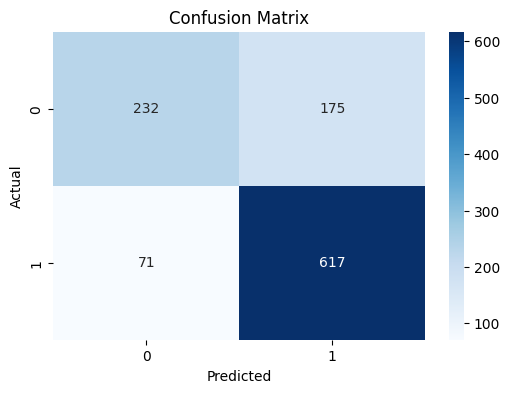


Classification Report:
              precision    recall  f1-score   support

           0       0.77      0.57      0.65       407
           1       0.78      0.90      0.83       688

    accuracy                           0.78      1095
   macro avg       0.77      0.73      0.74      1095
weighted avg       0.77      0.78      0.77      1095



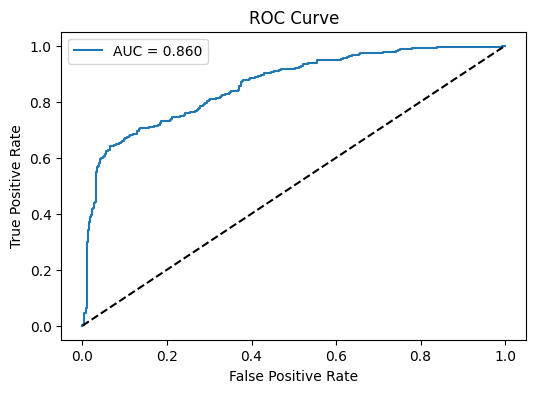

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc
from sklearn.linear_model import LogisticRegression
import seaborn as sns

# -----------------------------
# 1. Load dataset
# -----------------------------
data = pd.read_csv("Datasets.csv")

# -----------------------------
# 2. Remove non-numeric columns
# -----------------------------
non_numeric_cols = ['ID', 'Sender_IP', 'Target_IP']
X = data.drop(columns=non_numeric_cols + ['class'])
y = data['class']

# -----------------------------
# 3. Scale features
# -----------------------------
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# -----------------------------
# 4. Train-test split
# -----------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

# -----------------------------
# 5. Train model
# -----------------------------
model = LogisticRegression(max_iter=500)
model.fit(X_train, y_train)

# -----------------------------
# 6. Predictions
# -----------------------------
y_pred = model.predict(X_test)
y_pred_probs = model.predict_proba(X_test)[:, 1]

# -----------------------------
# 7. Confusion Matrix
# -----------------------------
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# -----------------------------
# 8. Precision, Recall, F1
# -----------------------------
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# -----------------------------
# 9. ROC Curve
# -----------------------------
fpr, tpr, _ = roc_curve(y_test, y_pred_probs)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6, 4))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()


In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense, LSTM, concatenate
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

# -------------------------------
# Load dataset
# -------------------------------
data = pd.read_csv("Datasets.csv")

# Remove non-numeric columns
non_numeric_cols = ['ID', 'Sender_IP', 'Target_IP']
X = data.drop(columns=non_numeric_cols + ['class'])
y = data['class']

# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

# Prepare LSTM input (expand dimension)
X_train_lstm = np.expand_dims(X_train, axis=-1)
X_test_lstm = np.expand_dims(X_test, axis=-1)

# -------------------------------
# Hybrid Model
# -------------------------------
# DNN branch
input_dnn = Input(shape=(X_train.shape[1],))
dense_layer = Dense(64, activation='relu')(input_dnn)
output_dnn = Dense(1, activation='sigmoid')(dense_layer)

# LSTM branch
input_lstm = Input(shape=(X_train.shape[1], 1))
lstm_layer = LSTM(64)(input_lstm)
output_lstm = Dense(1, activation='sigmoid')(lstm_layer)

# Combine
combined = concatenate([output_dnn, output_lstm])
final_output = Dense(1, activation='sigmoid')(combined)

model_30 = Model(inputs=[input_dnn, input_lstm], outputs=final_output)
model_30.compile(optimizer=Adam(learning_rate=0.001),
                 loss='binary_crossentropy',
                 metrics=['accuracy'])

# Early stopping
early_stopping = EarlyStopping(patience=5, restore_best_weights=True)

# -------------------------------
# Train for 30 EPOCHS
# -------------------------------
history_30 = model_30.fit(
    [X_train, X_train_lstm], y_train,
    epochs=30,
    batch_size=32,
    validation_data=([X_test, X_test_lstm], y_test),
    callbacks=[early_stopping]
)

# Final evaluation
loss_30, acc_30 = model_30.evaluate([X_test, X_test_lstm], y_test)
print(f"30 Epochs → Test Accuracy: {acc_30 * 100:.2f}%")


Epoch 1/30
137/137 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - accuracy: 0.5278 - loss: 0.7190 - val_accuracy: 0.7032 - val_loss: 0.6302
Epoch 2/30
137/137 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.7145 - loss: 0.6177 - val_accuracy: 0.7452 - val_loss: 0.5793
Epoch 3/30
137/137 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.7290 - loss: 0.5811 - val_accuracy: 0.7132 - val_loss: 0.5682
Epoch 4/30
137/137 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.7213 - loss: 0.5585 - val_accuracy: 0.7772 - val_loss: 0.5154
Epoch 5/30
137/137 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.7570 - loss: 0.5215 - val_accuracy: 0.7708 - val_loss: 0.4986
Epoch 6/30
137/137 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.7641 - loss: 0.5005 - val_accuracy: 0.7744 - val_loss: 0.4825
Epoch 7/30
137/137 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.7636 - loss: 0.4845 - val_accuracy: 0.7753 - val_loss: 0.4701
Epoch 8/30
137/137 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - accuracy: 0.7640 - loss: 0.4758 - val_accuracy: 

In [2]:
# -------------------------------
# Hybrid Model (new instance)
# -------------------------------
# DNN branch
input_dnn = Input(shape=(X_train.shape[1],))
dense_layer = Dense(64, activation='relu')(input_dnn)
output_dnn = Dense(1, activation='sigmoid')(dense_layer)

# LSTM branch
input_lstm = Input(shape=(X_train.shape[1], 1))
lstm_layer = LSTM(64)(input_lstm)
output_lstm = Dense(1, activation='sigmoid')(lstm_layer)

# Combine
combined = concatenate([output_dnn, output_lstm])
final_output = Dense(1, activation='sigmoid')(combined)

model_100 = Model(inputs=[input_dnn, input_lstm], outputs=final_output)
model_100.compile(optimizer=Adam(learning_rate=0.001),
                 loss='binary_crossentropy',
                 metrics=['accuracy'])

# Early stopping
early_stopping = EarlyStopping(patience=8, restore_best_weights=True)

# -------------------------------
# Train for 100 EPOCHS
# -------------------------------
history_100 = model_100.fit(
    [X_train, X_train_lstm], y_train,
    epochs=100,
    batch_size=32,
    validation_data=([X_test, X_test_lstm], y_test),
    callbacks=[early_stopping]
)

# Final evaluation
loss_100, acc_100 = model_100.evaluate([X_test, X_test_lstm], y_test)
print(f"100 Epochs → Test Accuracy: {acc_100 * 100:.2f}%")



Epoch 1/100
137/137 ━━━━━━━━━━━━━━━━━━━━ 15s 27ms/step - accuracy: 0.6659 - loss: 0.6273 - val_accuracy: 0.7260 - val_loss: 0.5732
Epoch 2/100
137/137 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 0.7264 - loss: 0.5624 - val_accuracy: 0.7443 - val_loss: 0.5207
Epoch 3/100
137/137 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.7449 - loss: 0.5258 - val_accuracy: 0.7516 - val_loss: 0.5087
Epoch 4/100
137/137 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.7599 - loss: 0.5061 - val_accuracy: 0.7945 - val_loss: 0.4789
Epoch 5/100
137/137 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.7865 - loss: 0.4809 - val_accuracy: 0.7781 - val_loss: 0.4771
Epoch 6/100
137/137 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.7809 - loss: 0.4762 - val_accuracy: 0.8018 - val_loss: 0.4566
Epoch 7/100
137/137 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.7767 - loss: 0.4729 - val_accuracy: 0.7973 - val_loss: 0.4520
Epoch 8/100
137/137 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.7873 - loss: 0.4603 - val_

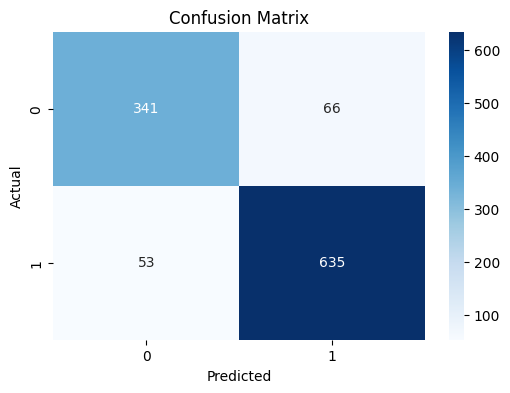

Classification Report:
              precision    recall  f1-score   support

           0       0.87      0.84      0.85       407
           1       0.91      0.92      0.91       688

    accuracy                           0.89      1095
   macro avg       0.89      0.88      0.88      1095
weighted avg       0.89      0.89      0.89      1095



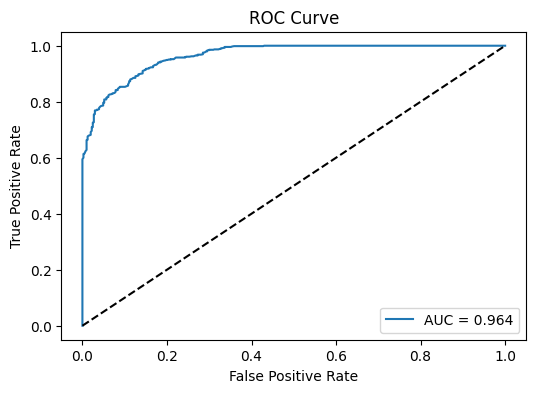

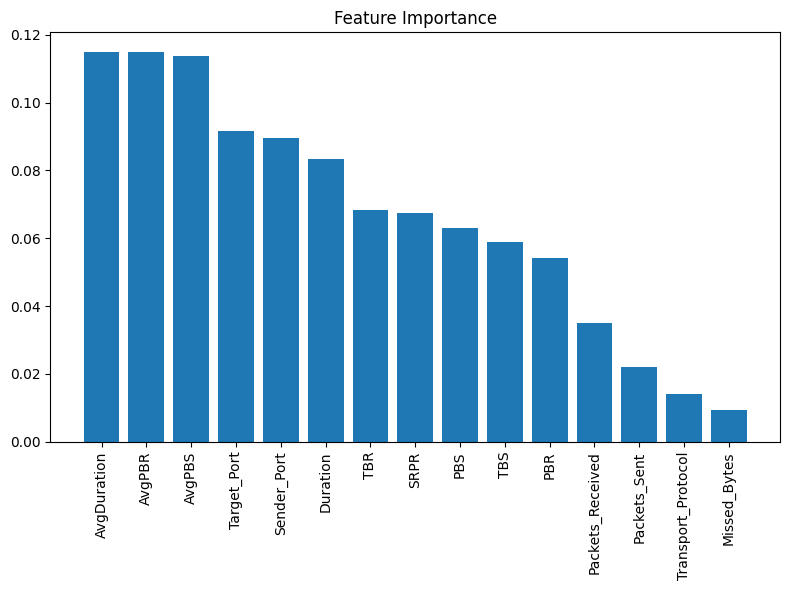

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    roc_curve,
    auc
)

# -------------------------
# Load Dataset
# -------------------------
data = pd.read_csv("Datasets.csv")

# Remove non-numeric ID/IP columns
non_numeric_cols = ["ID", "Sender_IP", "Target_IP"]
X = data.drop(columns=non_numeric_cols + ["class"])
y = data["class"]

# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

# -------------------------
# Train Random Forest
# -------------------------
rf = RandomForestClassifier(n_estimators=300, random_state=42)
rf.fit(X_train, y_train)

# Predictions
y_pred = rf.predict(X_test)
y_pred_prob = rf.predict_proba(X_test)[:, 1]

# -------------------------
# 1. Confusion Matrix
# -------------------------
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# -------------------------
# 2. Classification Report
# -------------------------
print("Classification Report:")
print(classification_report(y_test, y_pred))

# -------------------------
# 3. ROC Curve
# -------------------------
fpr, tpr, _ = roc_curve(y_test, y_pred_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6, 4))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
plt.plot([0,1], [0,1], "k--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

# -------------------------
# 4. Feature Importance (Optional)
# -------------------------
importances = rf.feature_importances_
indices = np.argsort(importances)[::-1]

plt.figure(figsize=(8, 6))
plt.title("Feature Importance")
plt.bar(range(X.shape[1]), importances[indices])
plt.xticks(range(X.shape[1]), X.columns[indices], rotation=90)
plt.tight_layout()
plt.show()


In [5]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

# Load dataset
data = pd.read_csv("Datasets.csv")

# Remove non-numeric columns
non_numeric_cols = ["ID", "Sender_IP", "Target_IP"]
X = data.drop(columns=non_numeric_cols + ["class"])
y = data["class"]

# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

# DNN Model
dnn_model = Sequential()
dnn_model.add(Dense(64, activation='relu', input_shape=(X_train.shape[1],)))
dnn_model.add(Dense(32, activation='relu'))
dnn_model.add(Dense(1, activation='sigmoid'))

dnn_model.compile(optimizer=Adam(0.001), loss='binary_crossentropy', metrics=['accuracy'])

early_stop = EarlyStopping(patience=5, restore_best_weights=True)

# Train DNN
history_dnn = dnn_


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


NameError: name 'dnn_' is not defined

In [7]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

# Load dataset
data = pd.read_csv("Datasets.csv")

# Remove non-numeric columns
non_numeric_cols = ["ID", "Sender_IP", "Target_IP"]
X = data.drop(columns=non_numeric_cols + ["class"])
y = data["class"]

# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

# ----------------------------------
# DNN MODEL (fixed, correct version)
# ----------------------------------
input_layer = Input(shape=(X_train.shape[1],))
dense1 = Dense(64, activation='relu')(input_layer)
dense2 = Dense(32, activation='relu')(dense1)
output_layer = Dense(1, activation='sigmoid')(dense2)

dnn_model = Model(inputs=input_layer, outputs=output_layer)
dnn_model.compile(
    optimizer=Adam(0.001),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

early_stop = EarlyStopping(patience=5, restore_best_weights=True)

# Train DNN
history_dnn = dnn_model.fit(
    X_train, y_train,
    epochs=50,
    batch_size=32,
    validation_data=(X_test, y_test),
    callbacks=[early_stop]
)

# Evaluate
loss_dnn, acc_dnn = dnn_model.evaluate(X_test, y_test)
print(f"DNN Test Accuracy: {acc_dnn * 100:.2f}%")


Epoch 1/50
137/137 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.6957 - loss: 0.5910 - val_accuracy: 0.7918 - val_loss: 0.4220
Epoch 2/50
137/137 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.7876 - loss: 0.4259 - val_accuracy: 0.8137 - val_loss: 0.4010
Epoch 3/50
137/137 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.7997 - loss: 0.3913 - val_accuracy: 0.8228 - val_loss: 0.3885
Epoch 4/50
137/137 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7976 - loss: 0.4004 - val_accuracy: 0.8000 - val_loss: 0.3896
Epoch 5/50
137/137 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7945 - loss: 0.3827 - val_accuracy: 0.8219 - val_loss: 0.3715
Epoch 6/50
137/137 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7974 - loss: 0.3870 - val_accuracy: 0.8228 - val_loss: 0.3697
Epoch 7/50
137/137 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8077 - loss: 0.3832 - val_accuracy: 0.8164 - val_loss: 0.3650
Epoch 8/50
137/137 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8007 - loss: 0.3813 - val_accuracy: 0.

In [9]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense, LSTM
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

# Load dataset
data = pd.read_csv("Datasets.csv")

# Remove non-numeric columns
non_numeric_cols = ["ID", "Sender_IP", "Target_IP"]
X = data.drop(columns=non_numeric_cols + ["class"])
y = data["class"]

# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

# Reshape for LSTM: (samples, timesteps, features)
X_train_lstm = np.expand_dims(X_train, axis=-1)
X_test_lstm = np.expand_dims(X_test, axis=-1)

# ----------------------------------
# LSTM MODEL (clean, same style)
# ----------------------------------
input_layer = Input(shape=(X_train.shape[1], 1))
lstm1 = LSTM(64)(input_layer)
dense1 = Dense(32, activation='relu')(lstm1)
output_layer = Dense(1, activation='sigmoid')(dense1)

lstm_model = Model(inputs=input_layer, outputs=output_layer)
lstm_model.compile(
    optimizer=Adam(0.001),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

early_stop = EarlyStopping(patience=5, restore_best_weights=True)

# Train LSTM
history_lstm = lstm_model.fit(
    X_train_lstm, y_train,
    epochs=50,
    batch_size=32,
    validation_data=(X_test_lstm, y_test),
    callbacks=[early_stop]
)

# Evaluate
loss_lstm, acc_lstm = lstm_model.evaluate(X_test_lstm, y_test)
print(f"LSTM Test Accuracy: {acc_lstm * 100:.2f}%")


Epoch 1/50
137/137 ━━━━━━━━━━━━━━━━━━━━ 7s 19ms/step - accuracy: 0.6682 - loss: 0.6182 - val_accuracy: 0.7224 - val_loss: 0.4869
Epoch 2/50
137/137 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.7131 - loss: 0.5009 - val_accuracy: 0.7616 - val_loss: 0.4477
Epoch 3/50
137/137 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - accuracy: 0.7345 - loss: 0.4618 - val_accuracy: 0.7772 - val_loss: 0.4318
Epoch 4/50
137/137 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 0.7545 - loss: 0.4519 - val_accuracy: 0.7781 - val_loss: 0.4070
Epoch 5/50
137/137 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.7663 - loss: 0.4281 - val_accuracy: 0.7963 - val_loss: 0.3881
Epoch 6/50
137/137 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.7801 - loss: 0.3997 - val_accuracy: 0.7973 - val_loss: 0.3942
Epoch 7/50
137/137 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.7727 - loss: 0.4188 - val_accuracy: 0.8009 - val_loss: 0.3832
Epoch 8/50
137/137 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.7838 - loss: 0.4047 - val_accuracy:

35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step


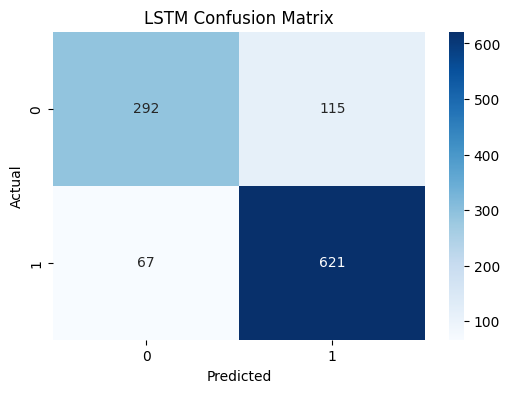

LSTM Classification Report:
              precision    recall  f1-score   support

           0       0.81      0.72      0.76       407
           1       0.84      0.90      0.87       688

    accuracy                           0.83      1095
   macro avg       0.83      0.81      0.82      1095
weighted avg       0.83      0.83      0.83      1095



In [10]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

# Predictions
y_pred_lstm = lstm_model.predict(X_test_lstm)
y_pred_lstm_label = (y_pred_lstm > 0.5).astype(int)

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_lstm_label)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("LSTM Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# Classification Metrics (Precision, Recall, F1)
print("LSTM Classification Report:")
print(classification_report(y_test, y_pred_lstm_label))


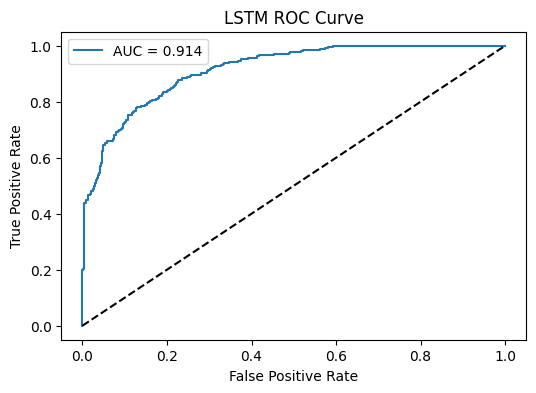

In [11]:
from sklearn.metrics import roc_curve, auc

fpr, tpr, _ = roc_curve(y_test, y_pred_lstm)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,4))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
plt.plot([0,1],[0,1],'k--')
plt.title("LSTM ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()


In [12]:
print("MODEL PERFORMANCE COMPARISON")
print("-----------------------------")
print(f"DNN Accuracy : {acc_dnn * 100:.2f}%")
print(f"LSTM Accuracy: {acc_lstm * 100:.2f}%")


MODEL PERFORMANCE COMPARISON
-----------------------------
DNN Accuracy : 82.56%
LSTM Accuracy: 83.38%
